In [1]:
import os
import math
import graphufs

import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import typing as t
import pandas as pd
import seaborn as sns
import matplotlib.cm as cm
import matplotlib.colors as mcolors

from weatherbench2 import schema
#from weatherbench2.derived_variables import ZonalEnergySpectrum

In [2]:
plt.style.use("graphufs.plotstyle")

In [3]:
class DerivedVariable:
  """Derived variable base class."""

  @property
  def base_variables(self) -> list[str]:
    """Return a list of base variables."""
    return []

  @property
  def core_dims(self) -> t.Tuple[t.Tuple[t.List[str], ...], t.List[str]]:
    """Return core dimensions needed for computing this variable.

    Returns a tuple, where the first element is a tuple of all core dimensions
    for input (base) variables, and the second element is a tuple of all core
    dimensions on the output. For more details on the concept of "core
    dimensions", see xarray.apply_ufunc.
    """
    raise NotImplementedError

  @property
  def all_input_core_dims(self) -> set[str]:
    """The set of all input core dimensions."""
    return set().union(*self.core_dims[0])

  def compute(self, dataset: xr.Dataset) -> xr.DataArray:
    """Compute derived variable, returning it in a new DataArray."""
    raise NotImplementedError

In [4]:
# Similarly create classes for computing geostrophic velocity
class Vorticity(DerivedVariable):
    """Compute relative vorticity from velocity fields."""

    R = 6.371e6  # Earth's radius [m]

    @property
    def base_variables(self) -> list[str]:
        return ["uo", "vo"]

    @property
    def core_dims(self) -> t.Tuple[t.Tuple[t.List[str], ...], t.List[str]]:
        return (
            [["time", "lat", "lon"], ["time", "lat", "lon"]],   # uo, vo
            ["time", "lat", "lon"],                             # vorticity
        )

    def compute(self, dataset: xr.Dataset) -> xr.DataArray:
        u = dataset["uo"]
        v = dataset["vo"]
        lat = u["lat"]
        lon = u["lon"]

        # Convert degrees to radians
        lat_rad = np.deg2rad(lat)
        lon_rad = np.deg2rad(lon)

        # Grid spacing (assuming regular grid)
        dlat = np.gradient(lat_rad)
        dlon = np.gradient(lon_rad)

        dx = (self.R * np.cos(lat_rad)) * dlon  # m
        dy = self.R * dlat  # m

        dx = xr.DataArray(dx, coords={"lon": lon}, dims=["lon"])
        dy = xr.DataArray(dy, coords={"lat": lat}, dims=["lat"])

        # Compute gradients
        dv_dx = v.differentiate("lon") / dx
        du_dy = u.differentiate("lat") / dy

        # Broadcast for alignment
        dv_dx, du_dy = xr.align(dv_dx, du_dy, join="override")

        # Vorticity
        vort = dv_dx - du_dy
        vort.name = "vorticity"

        return vort

In [5]:
scratch = "/pscratch/sd/n/nagarwal"
fig_dir = os.path.join(os.getcwd(), "figures")

In [6]:
truths = ["Replay"]
models = [
    "ocn-only R4 T3M graphufs 6h",
    "ocn-only R5 T1M graphufs 24h",
]

In [7]:
varlist = [
    "SSH",
    "temp",
    "so",
    "uo",
    "vo",
]

In [8]:
# Ocean levels (z_l)
selected_z_l = [0, 50, 100, 400]
n_init = 365 # number of initial conditions to consider

In [9]:
duration = "240h"
model_inferences = {}
reference_truths = {}
        
for model in models:

    model_type, run, expt, pred_prefix, descrip = model.split(" ")
    print("model:", model.replace(" ", "_"))
    
    infer_dir = f"inference_{expt}" if len(expt)!=0 else "inference" 
    location = os.path.join(scratch, model_type, run, f"{infer_dir}/validation/")
    
    for truth in truths:
        # reference truth
        fname = f"{location}/{truth.lower()}.{duration}.zarr"
        ref_truth = xr.open_zarr(fname)
        reference_truths[truth] = ref_truth.isel(time=slice(None, n_init)).sel(z_l=selected_z_l, method="nearest")
        if truth.lower() == "Replay".lower():
            mask_2d = xr.where(reference_truths[truth]["SSH"].isel(time=0, lead_time=0)==0, 0, 1)
            mask_3d = xr.where(reference_truths[truth]["so"].isel(time=0, lead_time=0)==0, 0, 1)

        # impute the land regions as nans
        for var in varlist:
            if var.lower() == "ssh":
                reference_truths[truth]["SSH"] = reference_truths[truth]["SSH"].where(mask_2d, other=0)
            else:
                reference_truths[truth][var] = reference_truths[truth][var].where(mask_3d, other=0)
        
    # read model predictions
    fname = f"{location}/{pred_prefix.lower()}.{duration}.zarr"
    model_pred = xr.open_zarr(fname)
    
    # model name for storing data
    model_name = model.replace(" ", "_")

    # store the inference
    model_inferences[model_name] = model_pred.isel(time=slice(None, n_init)).sel(z_l=selected_z_l, method="nearest")

    # mask the inferences as nans -- just like in the reference truth
    for var in varlist:
        if var.lower() == "ssh":
            model_inferences[model_name]["SSH"] = model_inferences[model_name]["SSH"].where(mask_2d, other=0)
        else:
            model_inferences[model_name][var] = model_inferences[model_name][var].where(mask_3d, other=0)

model: ocn-only_R4_T3M_graphufs_6h
model: ocn-only_R5_T1M_graphufs_24h


# Vorticity

In [10]:
# Initialize
vort_model = {}
vort_truth = {}

vort = Vorticity()
for model in model_inferences.keys():
    vort_model[model] = vort.compute(dataset = model_inferences[model].load())
for truth in reference_truths.keys():
    vort_truth[truth] = vort.compute(dataset = reference_truths[truth].load())

ERROR! Session/line number was not unique in database. History logging moved to new session 2171


ValueError: operands could not be broadcast together with shapes (192,) (384,) 

## Plot latitude-mean zonal spectra

In [11]:
def plot_spectra_2d(
    spectra_inference: dict,
    spectra_truth: dict = None,
    lead_time: list = ["24h"],
    fields: tuple = ("SSH",),
    labels: tuple = None,
    suptitle: str = None,
    zoom: bool = False,
    save: bool = False,
    save_path: str = None,
):
    """
    Plot zonal spectra for multiple lead times and fields.

    Parameters:
    - spectra_inference: xarray.Dataset containing spectra from model
    - spectra_truth: xarray.Dataset containing spectra from truth
    - lead_time: list of strings (e.g. ["24h", "48h"])
    - fields: tuple of variable names
    - labels: tuple of display names for variables
    - zoom: whether to zoom into log scale region
    - save: whether to save figure
    - save_path: filename to save (required if save=True)
    """

    # Convert string lead times to np.timedelta64[h]
    lead_times_td = [np.timedelta64(int(t[:-1]), "h") for t in lead_time]

    
    nrows = len(fields)
    ncols = len(lead_times_td)
    
    fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5.5 * ncols, 4.5 * nrows), 
                            sharey="row", squeeze=False)
    
    for j, lt_td in enumerate(lead_times_td):
        for i, field in enumerate(fields):
            ax = axs[i, j]

            for model in spectra_inference.keys():
                da_inf = spectra_inference[model][field].sel(lead_time=lt_td).mean("latitude")

                # mean over all ICs
                if "time" in da_inf.dims:
                    da_inf = da_inf.mean("time")

                # plot
                da_inf.plot(ax=ax, x="zonal_wavenumber", label=f"{model}", linewidth=2)
                    
            if spectra_truth is not None:
                for truth in spectra_truth.keys():
                    da_truth = spectra_truth[truth][field].sel(lead_time=lt_td,).mean("latitude")

                    if "time" in da_truth.dims:
                        da_truth = da_truth.mean("time")
                    
                    da_truth.plot(ax=ax, x="zonal_wavenumber", label=f"{truth}", linewidth=2)

            # Axis config
            ax.set_xscale("log")
            ax.set_yscale("log")
            ax.set_xlabel("Zonal Wavenumber")
            if j == 0:
                ax.set_ylabel("Spectral Power")
            else:
                ax.set_ylabel("")

            if zoom:
                ax.set_xlim(10, None)
                ax.set_ylim(None, 1e6)

            # Title
            label = labels[i] if labels else field.replace("_", "")
            ax.set_title(f"{label} | Lead Time: {lead_time[j]}")

            # Aesthetics
            for spine in ["top", "right"]:
                ax.spines[spine].set_visible(False)
            ax.grid(True, linestyle=":", linewidth=0.5)

    # Legend outside plot
    handles, plot_labels = axs[0, 0].get_legend_handles_labels()
    fig.legend(handles, plot_labels, loc="upper right", bbox_to_anchor=(1.1, 0.7), fancybox=True, shadow=True)
    fig.suptitle(suptitle if suptitle is not None else f"Zonal spectra for {fields}")
    fig.tight_layout(rect=[0, 0, 0.98, 0.98])

    if save and save_path:
        fig.savefig(save_path, dpi=300)

    return fig, axs

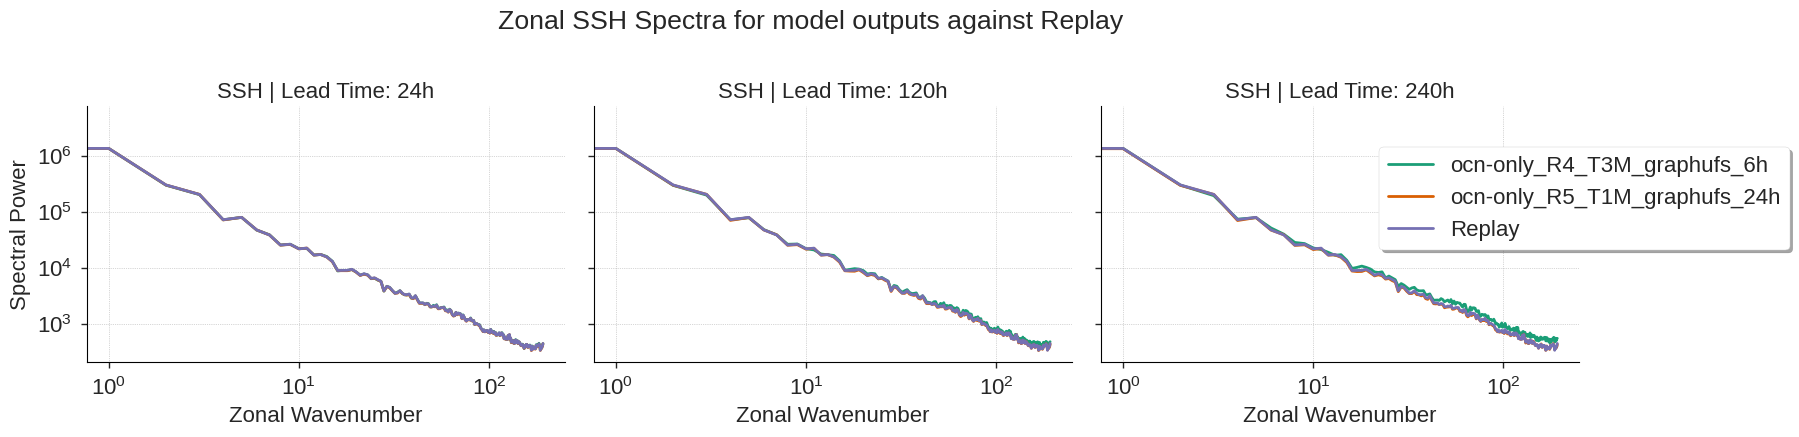

In [12]:
fields = ["SSH"]
fig, axs = plot_spectra_2d(spectra_model, 
                           spectra_truth, 
                           lead_time = ["24h", "120h", "240h"],
                           fields = fields,
                           labels = (["SSH"]),
                           suptitle="Zonal SSH Spectra for model outputs against Replay",
                           save = True,
                           save_path="./figures/compare_zonal_ssh_spectra_6h_vs_24h_against_replay.png"
                          )
plt.show()

In [13]:
def plot_spectra_grid_3d(
    spectra_inference: dict,
    spectra_truth: dict,
    variable: str = "temp",
    levels: list = [0, 50, 100],
    lead_times: list = ["24h", "48h"],
    zoom: bool = False,
    save: bool = False,
    save_path: str = None,
    suptitle: str = None,
):
    """
    Plot zonal spectra for a 3D variable with 'z_l' (depth) as rows and 'lead_time' as columns.

    Parameters:
    - spectra_inference: xarray.Dataset with spectra
    - spectra_truth: xarray.Dataset for ground truth
    - variable: 3D variable name (e.g., "temp")
    - levels: list of z_l (depth levels) to plot
    - lead_times: list of str lead times, e.g. ["24h", "48h"]
    - zoom: whether to zoom into log scale region
    - save: whether to save the figure
    - save_path: path to save the figure
    - title_prefix: string to prepend to each subplot title
    """
    # Convert lead times to timedelta64
    lead_times_td = [np.timedelta64(int(t[:-1]), "h") for t in lead_times]

    nrows = len(levels)
    ncols = len(lead_times_td)

    fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(4.5 * ncols, 3.5 * nrows), sharey="row",
                            sharex="all", squeeze=False)

    for i, z_val in enumerate(levels):
        for j, lt_td in enumerate(lead_times_td):
            ax = axs[i, j]

            for model in spectra_inference.keys():
                da_inf = spectra_inference[model][variable].sel(lead_time=lt_td).sel(z_l=z_val, method="nearest").mean("latitude")
                
                if "time" in da_inf.dims:
                    da_inf = da_inf.mean("time")

                # Plotting
                da_inf.plot(ax=ax, x="zonal_wavenumber", label=f"{model}", linewidth=2)

            if spectra_truth is not None:
                for truth in spectra_truth.keys():
                    da_truth = spectra_truth[truth][variable].sel(lead_time=lt_td).sel(z_l=z_val, method="nearest").mean("latitude")

                    if "time" in da_truth.dims:
                        da_truth = da_truth.mean("time")
                        
                    da_truth.plot(ax=ax, x="zonal_wavenumber", label=f"{truth}", linewidth=2)
            
            # Axes formatting
            ax.set_xscale("log")
            ax.set_yscale("log")
            if i == len(levels)-1:
                ax.set_xlabel("Zonal Wavenumber")
            else:
                ax.set_xlabel("")
            if j == 0:
                ax.set_ylabel(f"z_l = {da_truth.z_l.values:.2f}m")
            else:
                ax.set_ylabel("")

            if zoom:
                ax.set_xlim(10, None)
                ax.set_ylim(None, 1e6)
            if i == 0:
                title = f"Lead Time: {lead_times[j]}"
                ax.set_title(title,)
            else:
                ax.set_title("") # otherwise it puts those ugly xarray titles

            for spine in ["top", "right"]:
                ax.spines[spine].set_visible(False)
            ax.grid(True, linestyle=":", linewidth=0.5)

    # Legend and layout
    handles, labels = axs[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, bbox_to_anchor=(1.2, 0.75), fancybox=True, shadow=True)
    fig.suptitle(suptitle if suptitle is not None else f"Zonal spectra for {fields}")
    fig.tight_layout(rect=[0, 0, 0.98, 0.98])

    if save and save_path:
        fig.savefig(save_path, dpi=300)

    return fig, axs

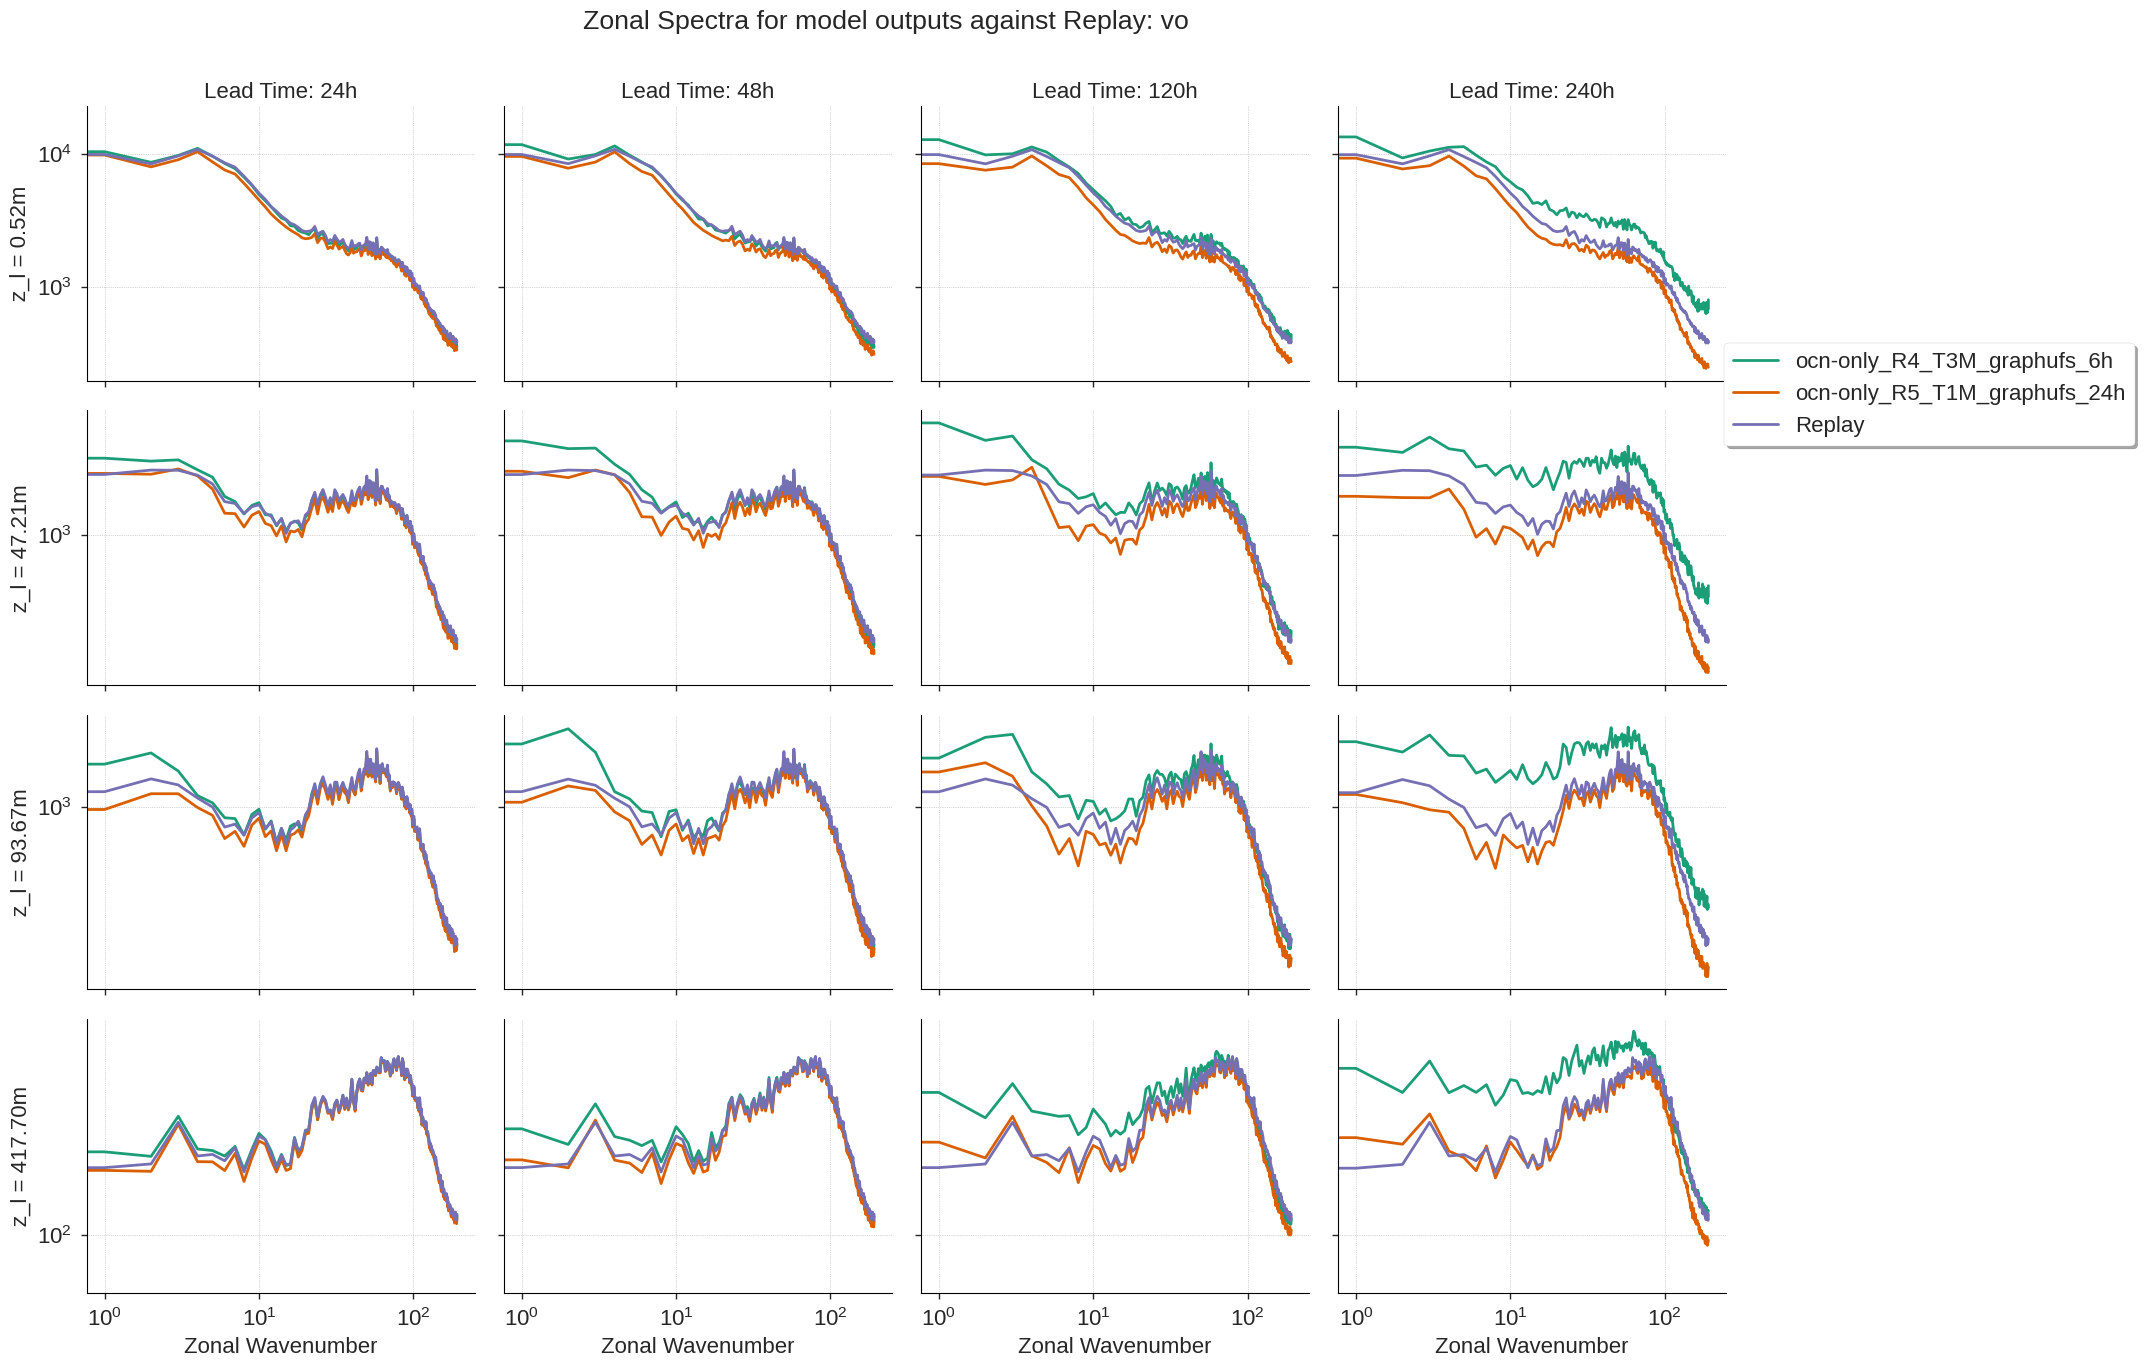

In [17]:
variable = "vo"

fig, axs = plot_spectra_grid_3d(
    spectra_inference=spectra_model,
    spectra_truth=spectra_truth,
    variable=variable,
    levels=[0, 50, 100, 400],
    lead_times=["24h", "48h", "120h", "240h"],
    suptitle=f"Zonal Spectra for model outputs against Replay: {variable}",
    save = True,
    save_path=f"./figures/compare_zonal_{variable}_spectra_6h_vs_24h_against_replay.png"
)

## Plot zonal spectra as a function of the latitude

In [55]:
def plot_zonal_spectra_map(spectra: xr.DataArray, 
                          title: str = "", 
                          cmap: str = "jet", 
                          log_scale: bool = True, 
                          vmin: float = None, 
                          vmax: float = None,
                          figsize=(8, 5),
                          save_path: str = None):
    """
    Plot 2D zonal spectra with latitude vs zonal wavenumber.

    Parameters:
    - spectra: xarray.DataArray with dims ("latitude", "zonal_wavenumber")
    - title: title of the plot
    - cmap: colormap for the heatmap
    - log_scale: use log10 for color normalization
    - vmin, vmax: value bounds for color scale
    - figsize: figure size
    - save_path: path to save the figure
    """

    if not {"latitude", "zonal_wavenumber"}.issubset(set(spectra.dims)):
        raise ValueError("Expected 'latitude' and 'zonal_wavenumber' in dimensions")

    data = spectra.values
    lats = spectra["latitude"].values
    wavenumbers = spectra["zonal_wavenumber"].values

    # Color scale
    if log_scale:
        data = np.log10(data)
        label = "log10(Spectral Power)"
    else:
        label = "Spectral Power"

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.contourf(wavenumbers, lats, data, cmap=cmap, vmin=vmin, vmax=vmax)

    # Axis settings
    ax.set_xlabel("Zonal Wavenumber", fontsize=12, fontweight="bold")
    ax.set_ylabel("Latitude", fontsize=12, fontweight="bold")
    ax.set_title(title or "2D Zonal Spectra", fontsize=14, fontweight="bold")
    ax.grid(True, which="both", linestyle=":", linewidth=0.5)

    # Log scale for x-axis
    #ax.set_xscale("log")

    # Colorbar
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(label, fontsize=12)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300)
        
    plt.show()

/tmp/ipykernel_2079982/4127439859.py:31: RuntimeWarning: divide by zero encountered in log10
  data = np.log10(data)


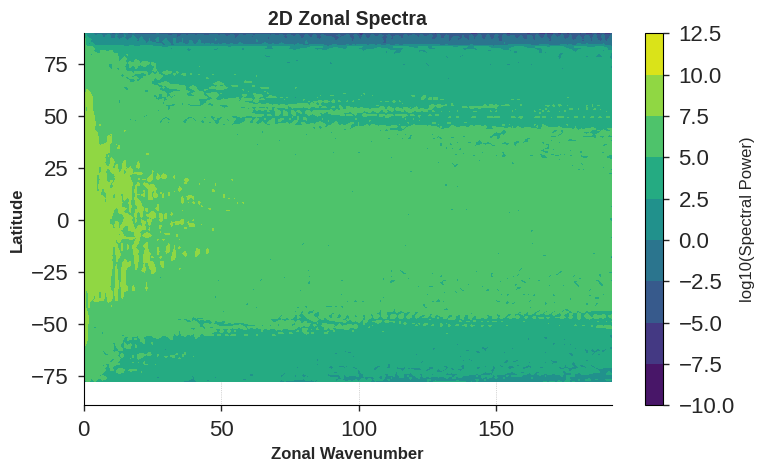

In [62]:
spectra = spectra_model["ocn-only_R5_T1M_graphufs_24h"]["temp"].isel(time=0, lead_time=-1, z_l=0)
plot_zonal_spectra_map(spectra, cmap="viridis") 
plt.show()

In [63]:
variable = "uo"
diff_spectra = spectra_model["ocn-only_R5_T1M_graphufs_24h"]["temp"] -  sp

SyntaxError: invalid syntax (53703842.py, line 1)

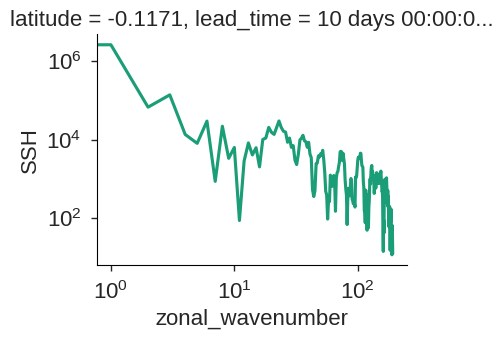

In [35]:
spectra.sel(latitude=0, method="nearest").plot(xscale="log", yscale="log")